### Cell 1 — Setup & config

In [ ]:
import numpy as np
import torch, torch.nn as nn
from utils import load_dataset, run_cv_bio_vs_biotopo, delong_roc_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng_seed = 13

# Load per-view datasets
Xb_tr, y_tr, Xb_te, y_te, b_cols = load_dataset("../datasets/BioFeats")
Xt_tr, yt_tr, Xt_te, yt_te, t_cols = load_dataset("../datasets/TopoFeats_BioEmb")
assert np.all(y_tr==yt_tr) and np.all(y_te==yt_te)

In [2]:
train_cfg = dict(hidden=(256,128), pdrop=0.1, epochs=20, batch_size=256,
                 lr=1e-3, weight_decay=1e-4, patience=5, min_delta=5e-4, seed=13)

out = run_cv_bio_vs_biotopo(Xb_tr, Xt_tr, y_tr, mode="concat",
                            n_splits=5, n_repeats=5,
                            undersample=True, train_cfg=train_cfg, base_seed=13)

print(out["summary"]["Bio"])
print(out["summary"]["BioTopo"])

# DeLong on pooled OOF
res = delong_roc_test(out["delong_ready"]["y"], out["delong_ready"]["bio"], out["delong_ready"]["biotopo"])
print(f"AUC(bio)={res['auc_a']:.4f}  AUC(bio+topo)={res['auc_b']:.4f}  Δ={res['delta']:.4f}  p={res['p']:.3g}")

{'AUC_mean': 0.9493675567007742, 'AUC_std': 0.001130782825324547, 'AP_mean': 0.9995398367863576, 'AP_std': 1.1906896821385005e-05, 'F1_mean': 0.9288311227306977, 'F1_std': 0.003241968884055596, 'ACC_mean': 0.8681203653555322, 'ACC_std': 0.0056355138993411675, 'PREC_mean': 0.9990759075661098, 'PREC_std': 1.729202442202307e-05, 'REC_mean': 0.8679141470896463, 'REC_std': 0.005684702004294668}
{'AUC_mean': 0.9558712908469319, 'AUC_std': 0.0009318421672563739, 'AP_mean': 0.999605515943758, 'AP_std': 1.2077399867077785e-05, 'F1_mean': 0.9391849549574456, 'F1_std': 0.0030293456740195838, 'ACC_mean': 0.8862817186761311, 'ACC_std': 0.005349537301295273, 'PREC_mean': 0.9990810124234807, 'PREC_std': 5.0334484435484555e-05, 'REC_mean': 0.8862282858293268, 'REC_std': 0.005423581566851503}
AUC(bio)=0.9490  AUC(bio+topo)=0.9551  Δ=0.0061  p=0.638


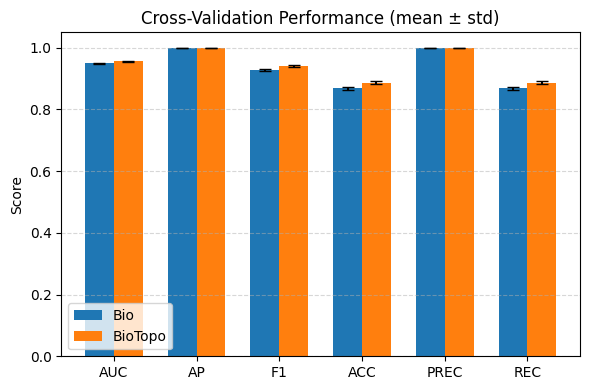

In [ ]:
from utils import plot_metric_bars
import matplotlib.pyplot as plt

plot_metric_bars(
    out["summary"],
    model_labels=("Bio", "BioTopo"),   
    metrics=("AUC", "AP", "F1", "ACC", "PREC", "REC"),  
    title="Cross-Validation Performance (mean ± std)"
)
plt.show()

In [5]:
out["summary"]

{'Bio': {'AUC_mean': 0.9493675567007742,
  'AUC_std': 0.001130782825324547,
  'AP_mean': 0.9995398367863576,
  'AP_std': 1.1906896821385005e-05,
  'F1_mean': 0.9288311227306977,
  'F1_std': 0.003241968884055596,
  'ACC_mean': 0.8681203653555322,
  'ACC_std': 0.0056355138993411675,
  'PREC_mean': 0.9990759075661098,
  'PREC_std': 1.729202442202307e-05,
  'REC_mean': 0.8679141470896463,
  'REC_std': 0.005684702004294668},
 'BioTopo': {'AUC_mean': 0.9558712908469319,
  'AUC_std': 0.0009318421672563739,
  'AP_mean': 0.999605515943758,
  'AP_std': 1.2077399867077785e-05,
  'F1_mean': 0.9391849549574456,
  'F1_std': 0.0030293456740195838,
  'ACC_mean': 0.8862817186761311,
  'ACC_std': 0.005349537301295273,
  'PREC_mean': 0.9990810124234807,
  'PREC_std': 5.0334484435484555e-05,
  'REC_mean': 0.8862282858293268,
  'REC_std': 0.005423581566851503}}